In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Dataset Loaded Successfully")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully


In [4]:
print(x_train.shape)

print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


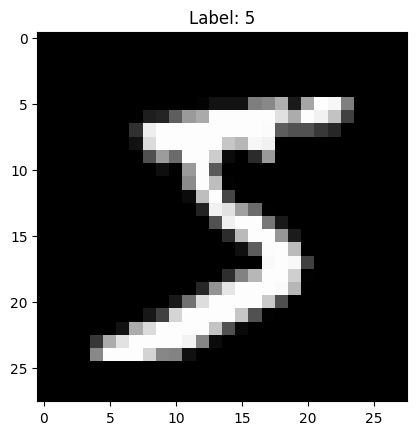

In [5]:
plt.imshow(x_train[0], cmap='gray')

plt.title(f"Label: {y_train[0]}")

plt.show()

In [6]:
x_train = x_train / 255.0

x_test = x_test / 255.0

In [7]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(
    Dense(100, activation='relu')
)

model.add(
    Dense(10, activation='softmax')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9556 - loss: 0.1499 - val_accuracy: 0.9807 - val_loss: 0.0611
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9851 - loss: 0.0505 - val_accuracy: 0.9843 - val_loss: 0.0464
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9851 - val_loss: 0.0434
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9874 - val_loss: 0.0381
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 0.9853 - val_loss: 0.0474


In [10]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9853 - loss: 0.0474
Accuracy: 0.9853000044822693


In [11]:
prediction = model.predict(x_test)

print(
    "Predicted Digit:",
    prediction[0].argmax()
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted Digit: 7


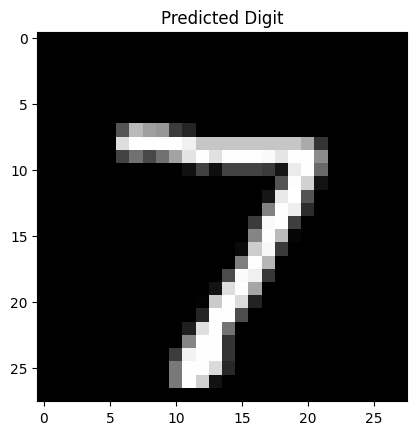

In [12]:
plt.imshow(
    x_test[0].reshape(28,28),
    cmap='gray'
)

plt.title("Predicted Digit")

plt.show()

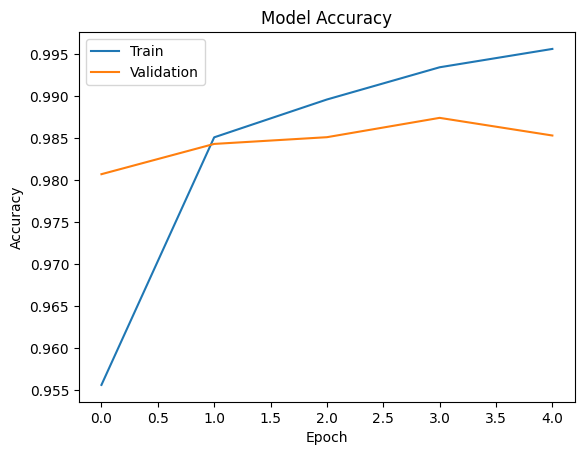

In [13]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()